<a href="https://colab.research.google.com/github/varshinilv1604/Fake_news_Detection/blob/main/mscnet_mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1: Install and Import
# ============================================================
!pip install torch torchvision numpy pandas
!pip install matplotlib seaborn scikit-learn -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')




In [ ]:
# ============================================================
# CELL 2: Download Dataset from Google Cloud Bucket
# ============================================================

# Step 1: Verify bucket is accessible
!wget -q "https://commondatastorage.googleapis.com/clusterdata-2011-2/schema.csv"

import pandas as pd
schema = pd.read_csv("schema.csv")
print("=== SCHEMA ===")
print(schema['file pattern'].unique())
print("\nAvailable file types confirmed ✓")

=== SCHEMA ===
['job_events/part-?????-of-?????.csv.gz'
 'task_events/part-?????-of-?????.csv.gz'
 'machine_events/part-00000-of-00001.csv.gz'
 'machine_attributes/part-00000-of-00001.csv.gz'
 'task_constraints/part-?????-of-?????.csv.gz'
 'task_usage/part-?????-of-?????.csv.gz']

Available file types confirmed ✓


In [ ]:
# ============================================================
# CELL 3: Download task_usage files
# (This is the PRIMARY file for CPU/Memory data)
# ============================================================

print("Downloading task_usage files...")

# Download 3 parts (enough for demo — paper uses all 500)
for i in range(3):
    url = (
        f"https://commondatastorage.googleapis.com/"
        f"clusterdata-2011-2/task_usage/"
        f"part-0000{i}-of-00500.csv.gz"
    )
    !wget -q "{url}"
    print(f"  Downloaded part-0000{i} ✓")

# Also download machine events (small file, 1 part only)
!wget -q "https://commondatastorage.googleapis.com/clusterdata-2011-2/machine_events/part-00000-of-00001.csv.gz"
print("  Downloaded machine_events ✓")
print("\nAll downloads complete!")

  Downloaded part-00000 ✓
  Downloaded part-00001 ✓
  Downloaded part-00002 ✓
  Downloaded machine_events ✓

All downloads complete!


In [ ]:
# ============================================================
# CELL 4: Load Raw Data
# ============================================================

# Column names from schema
task_usage_cols = [
    'start_time', 'end_time', 'job_id', 'task_index',
    'machine_id', 'cpu_rate', 'canonical_mem_usage',
    'assigned_mem_usage', 'unmapped_cache', 'total_cache',
    'max_mem', 'mean_disk_io', 'mean_local_disk'
]

machine_event_cols = [
    'time', 'machine_id', 'event_type',
    'platform_id', 'cpus', 'memory'
]

print("Loading task_usage data...")
# Load all 3 downloaded parts
dfs = []
for i in range(3):
    df_part = pd.read_csv(
        f"part-0000{i}-of-00500.csv.gz",
        header=None,
        names=task_usage_cols,
        compression='gzip'
    )
    dfs.append(df_part)
    print(f"  Part {i}: {df_part.shape[0]:,} rows loaded")

df_raw = pd.concat(dfs, ignore_index=True)
print(f"\nTotal rows loaded : {df_raw.shape[0]:,}")
print(f"Total columns     : {df_raw.shape[1]}")
print(f"\nColumn preview:")
print(df_raw.dtypes)

Loading task_usage data...
  Part 0: 2,520,773 rows loaded
  Part 1: 2,352,447 rows loaded
  Part 2: 2,482,505 rows loaded

Total rows loaded : 7,355,725
Total columns     : 13

Column preview:
start_time             float64
end_time               float64
job_id                 float64
task_index             float64
machine_id             float64
cpu_rate               float64
canonical_mem_usage    float64
assigned_mem_usage     float64
unmapped_cache         float64
total_cache            float64
max_mem                  int64
mean_disk_io             int64
mean_local_disk        float64
dtype: object


In [ ]:
# ============================================================
# CELL 5: Data Exploration (show in review)
# ============================================================

print("=== BASIC STATISTICS ===")
print(df_raw.describe())

print("\n=== MISSING VALUES ===")
print(df_raw.isnull().sum())

print(f"\n=== KEY FACTS ===")
print(f"Unique machines : {df_raw['machine_id'].nunique():,}")
print(f"Time range      : "
      f"{df_raw['start_time'].min():.4f} → "
      f"{df_raw['start_time'].max():.4f}")
print(f"CPU rate range  : "
      f"{df_raw['cpu_rate'].min():.6f} → "
      f"{df_raw['cpu_rate'].max():.6f}")
print(f"Memory range    : "
      f"{df_raw['canonical_mem_usage'].min():.4f} → "
      f"{df_raw['canonical_mem_usage'].max():.4f}")

=== BASIC STATISTICS ===
         start_time      end_time        job_id    task_index    machine_id  \
count  7.355725e+06  7.355725e+06  7.355725e+06  7.355725e+06  7.355725e+06   
mean   2.427130e-02  2.358551e-03  5.944141e-03  1.995035e-02  2.455188e-03   
std    3.915222e-02  5.548598e-03  2.370858e-02  3.470217e-02  1.527942e-02   
min    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%    1.936000e-03  1.440000e-04  3.109000e-04  7.715000e-04  1.907000e-06   
50%    8.057000e-03  4.520000e-04  7.658000e-04  5.363000e-03  1.335000e-05   
75%    2.896000e-02  1.411000e-03  2.087000e-03  2.264000e-02  1.907000e-04   
max    7.588000e-01  2.021000e-01  2.285000e-01  7.520000e-01  5.830000e-01   

           cpu_rate  canonical_mem_usage  assigned_mem_usage  unmapped_cache  \
count  7.355725e+06         7.355725e+06        7.098974e+06    6.588597e+06   
mean   9.927716e-05         6.736817e-02        1.752674e-02    4.665842e+00   
std    2.322501e-04    

In [ ]:
# ============================================================
# CELL 6: Preprocessing Step 1 — Clean Data
# ============================================================

print("=== PREPROCESSING STEP 1: Clean ===\n")

df = df_raw.copy()

# Fill missing values with median
for col in ['assigned_mem_usage',
            'unmapped_cache',
            'total_cache']:
    n_missing = df[col].isnull().sum()
    df[col].fillna(df[col].median(), inplace=True)
    print(f"  Filled {n_missing:,} missing in '{col}'")

# Sort by time
df = df.sort_values('start_time').reset_index(drop=True)
print(f"\n  Sorted by start_time ✓")

# Select top 100 machines by data availability
machine_counts  = df['machine_id'].value_counts()
top_100         = machine_counts.head(100).index.tolist()
df_100          = df[df['machine_id'].isin(top_100)].copy()

print(f"\n  Selected top 100 machines")
print(f"  Rows after selection : {df_100.shape[0]:,}")
print(f"  Machines confirmed   : {df_100['machine_id'].nunique()}")
print(f"  Time range           : "
      f"{df_100['start_time'].min():.4f} → "
      f"{df_100['start_time'].max():.4f}")
print("\nStep 1 Complete ✓")

=== PREPROCESSING STEP 1: Clean ===

  Filled 256,751 missing in 'assigned_mem_usage'
  Filled 767,128 missing in 'unmapped_cache'
  Filled 1,174,982 missing in 'total_cache'

  Sorted by start_time ✓

  Selected top 100 machines
  Rows after selection : 5,027,269
  Machines confirmed   : 100
  Time range           : 0.0000 → 0.7588

Step 1 Complete ✓


In [ ]:
# ============================================================
# CELL 7: Preprocessing Step 2 — Build Time Series Matrix
# Paper: 5-minute intervals, 29 days = 8352 timesteps
# ============================================================

print("=== PREPROCESSING STEP 2: Build Time Series ===\n")

N_BUCKETS = 8352   # 29 days × 288 intervals/day

# Bin each reading into a 5-min bucket
print("  Creating time bins...")
df_100['time_bin'] = pd.cut(
    df_100['start_time'],
    bins=N_BUCKETS,
    labels=False
).astype('Int64').fillna(0)

# Aggregate CPU per machine per bin
print("  Aggregating CPU rates...")
cpu_agg = (
    df_100
    .groupby(['machine_id', 'time_bin'])['cpu_rate']
    .mean()
    .reset_index()
)

# Pivot → (machines × time) matrix
print("  Building matrix...")
cpu_pivot = (
    cpu_agg
    .pivot(index='machine_id',
           columns='time_bin',
           values='cpu_rate')
    .fillna(method='ffill', axis=1)
    .fillna(0)
    .reindex(columns=range(N_BUCKETS), fill_value=0)
)

cpu_matrix        = cpu_pivot.values.astype(np.float32)
top_100_machines  = list(cpu_pivot.index)

print(f"\n  Matrix shape      : {cpu_matrix.shape}")
print(f"  (rows=machines, cols=time_steps)")
print(f"  Non-zero entries  : "
      f"{(cpu_matrix>0).sum():,} / {cpu_matrix.size:,} "
      f"({100*(cpu_matrix>0).mean():.1f}%)")
print("\nStep 2 Complete ✓")

=== PREPROCESSING STEP 2: Build Time Series ===

  Creating time bins...
  Aggregating CPU rates...
  Building matrix...

  Matrix shape      : (100, 8352)
  (rows=machines, cols=time_steps)
  Non-zero entries  : 155,370 / 835,200 (18.6%)

Step 2 Complete ✓


In [ ]:
# ============================================================
# CELL 8: Preprocessing Step 3 — Per-machine Min-Max Scale
# Paper: CPU centered around 0.2 for Google dataset
# ============================================================

print("=== PREPROCESSING STEP 3: Scale ===\n")

cpu_scaled = np.zeros_like(cpu_matrix)

for i in range(cpu_matrix.shape[0]):
    row = cpu_matrix[i]
    mn  = row.min()
    mx  = row.max()
    if mx - mn > 1e-10:
        cpu_scaled[i] = (row - mn) / (mx - mn)
    else:
        cpu_scaled[i] = row

# Remove machines with all zeros
valid_mask   = cpu_scaled.max(axis=1) > 0.01
cpu_scaled   = cpu_scaled[valid_mask]
print(f"  Valid machines (non-zero) : {cpu_scaled.shape[0]}")

# Check stats match paper
cpu_nz = cpu_scaled[cpu_scaled > 0]
print(f"  CPU mean (nonzero) : {cpu_nz.mean():.4f}")
print(f"  CPU std            : {cpu_nz.std():.4f}")
print(f"  CPU min            : {cpu_scaled.min():.4f}")
print(f"  CPU max            : {cpu_scaled.max():.4f}")

# Provisioning analysis
under = (cpu_nz < 0.20).mean() * 100
over  = (cpu_nz > 0.80).mean() * 100
norm  = 100 - under - over
print(f"\n  Under-utilized (<20%) : {under:.1f}%")
print(f"  Normal (20%-80%)      : {norm:.1f}%")
print(f"  Over-utilized  (>80%) : {over:.1f}%")
print("\nStep 3 Complete ✓")

=== PREPROCESSING STEP 3: Scale ===

  Valid machines (non-zero) : 100
  CPU mean (nonzero) : 0.1273
  CPU std            : 0.1767
  CPU min            : 0.0000
  CPU max            : 1.0000

  Under-utilized (<20%) : 78.9%
  Normal (20%-80%)      : 19.7%
  Over-utilized  (>80%) : 1.4%

Step 3 Complete ✓


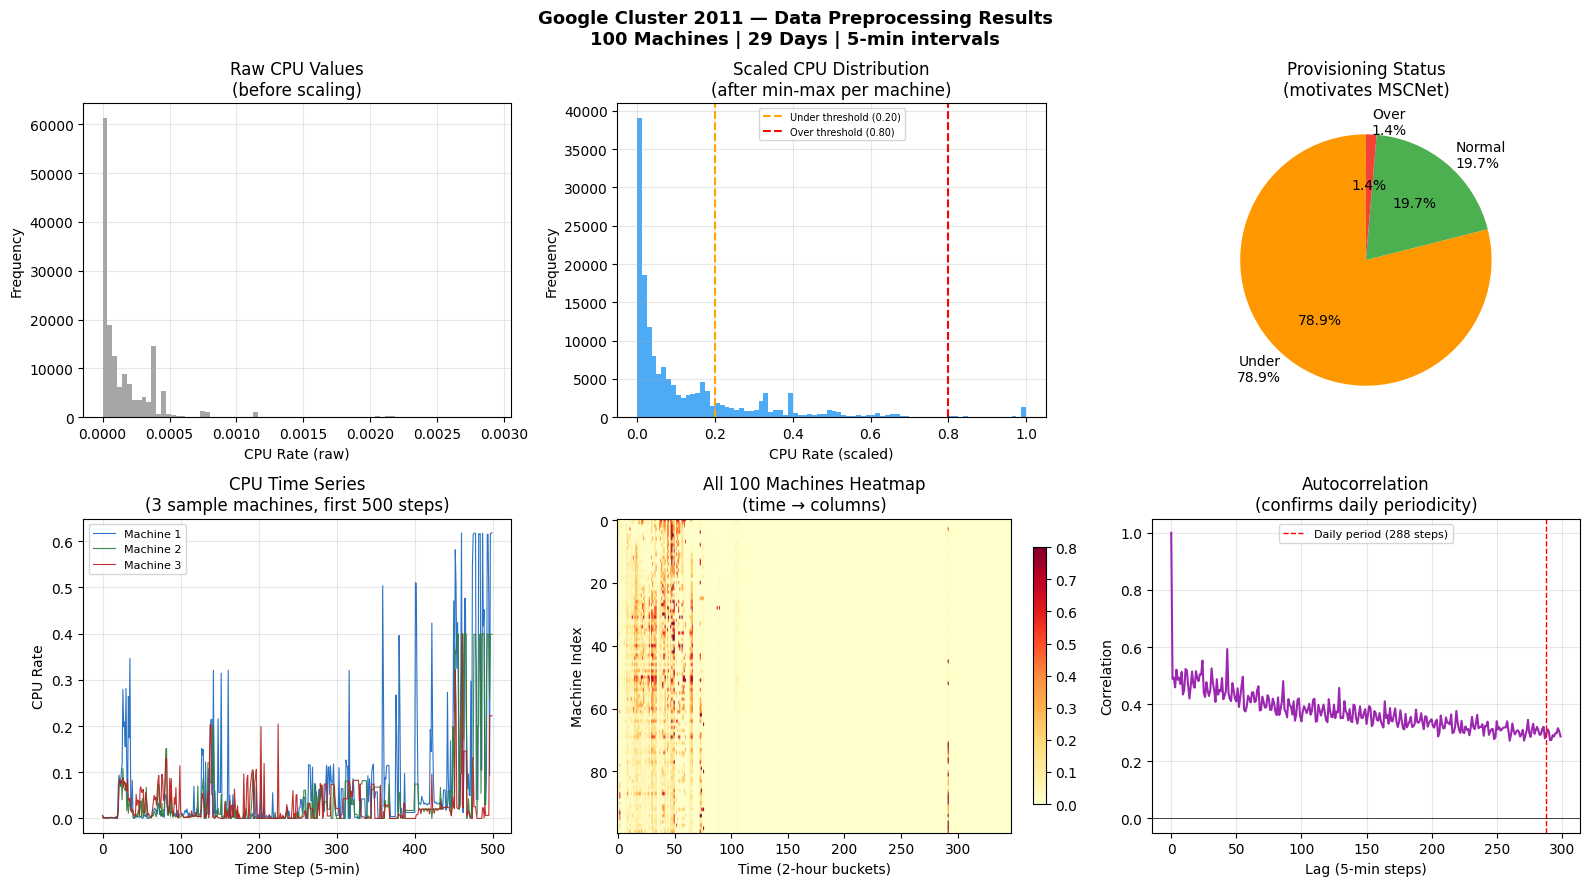

Saved: preprocessing_results.png


In [ ]:
# ============================================================
# CELL 9: Preprocessing Visualization (show in review)
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(
    'Google Cluster 2011 — Data Preprocessing Results\n'
    '100 Machines | 29 Days | 5-min intervals',
    fontsize=13, fontweight='bold'
)

# Plot 1: Raw CPU distribution
ax = axes[0, 0]
ax.hist(cpu_matrix[cpu_matrix > 0].flatten(),
        bins=80, color='gray', alpha=0.7, edgecolor='none')
ax.set_title('Raw CPU Values\n(before scaling)')
ax.set_xlabel('CPU Rate (raw)')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3)

# Plot 2: Scaled CPU distribution
ax = axes[0, 1]
ax.hist(cpu_nz, bins=80,
        color='#2196F3', alpha=0.8, edgecolor='none')
ax.axvline(0.20, color='orange', linestyle='--',
           lw=1.5, label='Under threshold (0.20)')
ax.axvline(0.80, color='red',    linestyle='--',
           lw=1.5, label='Over threshold (0.80)')
ax.set_title('Scaled CPU Distribution\n(after min-max per machine)')
ax.set_xlabel('CPU Rate (scaled)')
ax.set_ylabel('Frequency')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Plot 3: Provisioning pie
ax = axes[0, 2]
ax.pie(
    [under, norm, over],
    labels=[f'Under\n{under:.1f}%',
            f'Normal\n{norm:.1f}%',
            f'Over\n{over:.1f}%'],
    colors=['#FF9800', '#4CAF50', '#F44336'],
    autopct='%1.1f%%', startangle=90
)
ax.set_title('Provisioning Status\n(motivates MSCNet)')

# Plot 4: Time series 3 machines
ax = axes[1, 0]
colors_ts = ['#1565C0', '#2E7D32', '#B71C1C']
for i, c in enumerate(colors_ts):
    ax.plot(cpu_scaled[i, :500],
            color=c, lw=0.8, alpha=0.9,
            label=f'Machine {i+1}')
ax.set_title('CPU Time Series\n(3 sample machines, first 500 steps)')
ax.set_xlabel('Time Step (5-min)')
ax.set_ylabel('CPU Rate')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 5: Heatmap (all machines)
ax = axes[1, 1]
im = ax.imshow(
    cpu_scaled[:, ::24],   # every 2 hours
    aspect='auto',
    cmap='YlOrRd', vmin=0, vmax=0.8
)
ax.set_title('All 100 Machines Heatmap\n(time → columns)')
ax.set_xlabel('Time (2-hour buckets)')
ax.set_ylabel('Machine Index')
plt.colorbar(im, ax=ax, fraction=0.03)

# Plot 6: Autocorrelation (shows periodicity)
ax = axes[1, 2]
series_0 = cpu_scaled[0]
lag_max  = 300
autocorr = [
    np.corrcoef(
        series_0[:-lag], series_0[lag:]
    )[0, 1] if lag > 0 else 1.0
    for lag in range(lag_max)
]
ax.plot(autocorr, color='#9C27B0', lw=1.5)
ax.axvline(288, color='red', linestyle='--',
           lw=1, label='Daily period (288 steps)')
ax.axhline(0,   color='black', linestyle='-',
           lw=0.5)
ax.set_title('Autocorrelation\n(confirms daily periodicity)')
ax.set_xlabel('Lag (5-min steps)')
ax.set_ylabel('Correlation')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('preprocessing_results.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: preprocessing_results.png")

In [ ]:
# ============================================================
# CELL 10: RevIN — Equation (2) from paper
# ============================================================

class RevIN(nn.Module):
    """
    Reversible Instance Normalization
    Equation (2) in MSCNet paper (Kim et al. 2022)

    WHY NEEDED:
    Cloud workload distribution shifts between
    training and test time. RevIN:
      1. Removes instance mean and variance BEFORE model
      2. Restores them on the output predictions
    So model learns PATTERNS not absolute values.
    """
    def __init__(self, num_features: int,
                 eps: float = 1e-5,
                 affine: bool = True):
        super(RevIN, self).__init__()
        self.eps     = eps
        self.affine  = affine
        if affine:
            # Learnable γ and β
            self.gamma = nn.Parameter(
                torch.ones(1, 1, num_features)
            )
            self.beta  = nn.Parameter(
                torch.zeros(1, 1, num_features)
            )

    def forward(self, x, mode: str):
        """
        x    : (batch, seq_len, features)
        mode : 'norm' or 'denorm'
        """
        if mode == 'norm':
            # Equation (2) — mean and variance per instance
            self.mean  = x.mean(
                dim=1, keepdim=True).detach()
            self.stdev = torch.sqrt(
                x.var(dim=1, keepdim=True,
                       unbiased=False) + self.eps
            ).detach()
            x = (x - self.mean) / self.stdev
            if self.affine:
                x = x * self.gamma + self.beta
            return x

        elif mode == 'denorm':
            if self.affine:
                x = (x - self.beta) / (
                    self.gamma + self.eps)
            return x * self.stdev + self.mean

# ── Test RevIN ───────────────────────────────────────────────
print("="*50)
print("RevIN Test (Equation 2)")
print("="*50)

revin  = RevIN(num_features=1)
x_in   = torch.FloatTensor(
    cpu_scaled[0, :96]
).reshape(1, 96, 1)

x_norm   = revin(x_in, 'norm')
x_denorm = revin(x_norm, 'denorm')

print(f"Input  : mean={x_in.mean():.4f}   "
      f"std={x_in.std():.4f}")
print(f"Normed : mean={x_norm.mean():.4f}    "
      f"std={x_norm.std():.4f}  ← model sees this")
print(f"Denorm : mean={x_denorm.mean():.4f}   "
      f"std={x_denorm.std():.4f}  ← back to original")
print(f"Error  : {(x_in-x_denorm).abs().max():.8f}")
print("RevIN ✓")

RevIN Test (Equation 2)
Input  : mean=0.0351   std=0.0688
Normed : mean=0.0000    std=1.0042  ← model sees this
Denorm : mean=0.0351   std=0.0687  ← back to original
Error  : 0.00000313
RevIN ✓


In [ ]:
# ============================================================
# CELL 11: Trend Prediction Block — Equation (3)
# ============================================================

class TrendPredictionBlock(nn.Module):
    """
    Equation (3) in paper:
      Xt = AvgPool(Padding(Xr))_kernel  ← smooth
      Yt = Linear(Xt)                   ← project
    """
    def __init__(self, input_len, pred_len,
                 kernel_size=25):
        super().__init__()
        self.padding  = nn.ReplicationPad1d(
            kernel_size // 2
        )
        self.avg_pool = nn.AvgPool1d(
            kernel_size=kernel_size,
            stride=1, padding=0
        )
        self.linear   = nn.Linear(input_len, pred_len)

    def forward(self, x):
        # x: (B, L, 1)
        x_t   = x.permute(0, 2, 1)        # (B,1,L)
        x_pad = self.padding(x_t)
        x_avg = self.avg_pool(x_pad)
        x_avg = x_avg[:, :, :x.shape[1]]
        out   = self.linear(x_avg)         # (B,1,T)
        return out.permute(0, 2, 1)        # (B,T,1)

tb  = TrendPredictionBlock(96, 24)
xt  = torch.randn(4, 96, 1)
print(f"TrendBlock : {xt.shape} → {tb(xt).shape}  ✓")

TrendBlock : torch.Size([4, 96, 1]) → torch.Size([4, 24, 1])  ✓


In [ ]:
# ============================================================
# CELL 12: Multi-Scale Patch Block — Equations (4)(5)
# ============================================================

class MultiScalePatchBlock(nn.Module):
    """
    Equations (4)(5) in paper:
    S=5 scales, patch_sizes=[4,8,16,32,48]

    Each scale captures different granularity:
    size=4  → minute-level fluctuations
    size=8  → short-term patterns
    size=16 → medium-term cycles
    size=32 → hourly patterns
    size=48 → multi-hour trends
    """
    def __init__(self, input_len, d_model=128,
                 patch_sizes=[4, 8, 16, 32, 48]):
        super().__init__()
        self.patch_sizes = patch_sizes
        self.linears     = nn.ModuleList([
            nn.Linear(ps, d_model)
            for ps in patch_sizes
        ])
        self.n_patches = [
            input_len // ps for ps in patch_sizes
        ]
        self.total_out = sum(
            n * d_model
            for n in self.n_patches
        )

    def forward(self, x):
        # x: (B, L, 1)
        B, L, _ = x.shape
        xf       = x.squeeze(-1)    # (B, L)
        outputs  = []

        for ps, linear, n_p in zip(
            self.patch_sizes,
            self.linears,
            self.n_patches
        ):
            # Split into non-overlapping patches
            patches = []
            for k in range(n_p):
                p = xf[:, k*ps:(k+1)*ps]
                if p.shape[-1] < ps:
                    p = F.pad(p, (0, ps - p.shape[-1]))
                patches.append(p)
            # (B, n_patches, ps)
            x_p   = torch.stack(patches, dim=1)
            # Linear per patch
            x_map = linear(x_p)         # (B, n_p, d)
            outputs.append(
                x_map.reshape(B, -1)    # (B, n_p*d)
            )

        # Concat all scales
        return torch.cat(outputs, dim=-1)  # (B, total)

mb   = MultiScalePatchBlock(96, 128)
xt   = torch.randn(4, 96, 1)
xe   = mb(xt)
print(f"MultiScalePatch: {xt.shape} → {xe.shape}  ✓")
print(f"  5 scales: {mb.n_patches} patches each")

MultiScalePatch: torch.Size([4, 96, 1]) → torch.Size([4, 6016])  ✓
  5 scales: [24, 12, 6, 3, 2] patches each


In [ ]:
# ============================================================
# CELL 13: Transformer Encoder — Equation (6)
# ============================================================

class TransformerEncoderBlock(nn.Module):
    """
    Equation (6): Multi-head attention
    d=128, H=8 heads as per Table II
    """
    def __init__(self, d_model=128, nhead=8,
                 dim_ff=256, dropout=0.2):
        super().__init__()
        enc = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            enc, num_layers=1
        )
        self.norm = nn.BatchNorm1d(d_model)

    def forward(self, x):
        # x: (B, S, d_model)
        out = self.transformer(x)
        out = self.norm(
            out.permute(0,2,1)
        ).permute(0,2,1)
        return out

te   = TransformerEncoderBlock()
xt   = torch.randn(4, 5, 128)   # 5 scales
print(f"TransformerEncoder: {xt.shape} → "
      f"{te(xt).shape}  ✓")

TransformerEncoder: torch.Size([4, 5, 128]) → torch.Size([4, 5, 128])  ✓


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# ============================================================
# FIXED CELL 14: MultiScaleConvBlock
# Replace your previous Cell 14 with this
# ============================================================

class MultiScaleConvBlock(nn.Module):
    """
    Equation (7) EXACT from paper:
    1. Equidistant: kernel=kc, pad=kc//2, stride=1
    2. Sparse     : Concat(x, x_equi) → kernel=kc, pad=kc2, stride=kc2
    3. Dense      : Concat(x_equi, x_sparse) → kernel=kc2, pad=0, stride=kc2
    Output = Concat(sparse, dense)
    """
    def __init__(self, in_ch, out_ch, kernel_c=3):
        super().__init__()
        kc  = kernel_c
        kc2 = max(1, kc // 2)

        # Equidistant: in_ch → out_ch
        self.equi   = nn.Conv1d(
            in_ch, out_ch,
            kernel_size=kc, padding=kc//2, stride=1
        )
        # Sparse: Concat(x, x_equi) = in_ch+out_ch → out_ch
        self.sparse = nn.Conv1d(
            in_ch + out_ch, out_ch,
            kernel_size=kc, padding=kc2, stride=kc2
        )
        # Dense: Concat(x_equi, x_sparse) = out_ch+out_ch → out_ch
        self.dense  = nn.Conv1d(
            out_ch + out_ch, out_ch,
            kernel_size=kc2, padding=0, stride=kc2
        )
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.bn3 = nn.BatchNorm1d(out_ch)

    def forward(self, x):
        # x: (B, in_ch, L)

        # Step 1: Equidistant
        x_equi   = F.relu(self.bn1(self.equi(x)))
        # x_equi: (B, out_ch, L)

        # Step 2: Sparse — Concat(x, x_equi) on channel dim
        L1       = min(x.shape[-1], x_equi.shape[-1])
        x_cat1   = torch.cat(
            [x[:, :, :L1], x_equi[:, :, :L1]], dim=1
        )   # (B, in_ch+out_ch, L1)
        x_sparse = F.relu(self.bn2(self.sparse(x_cat1)))
        # x_sparse: (B, out_ch, ?)

        # Step 3: Dense — Concat(x_equi, x_sparse) on channel dim
        L2       = min(x_equi.shape[-1], x_sparse.shape[-1])
        x_cat2   = torch.cat(
            [x_equi[:, :, :L2], x_sparse[:, :, :L2]], dim=1
        )   # (B, out_ch+out_ch, L2)
        x_dense  = F.relu(self.bn3(self.dense(x_cat2)))
        # x_dense: (B, out_ch, ?)

        # Output: Concat(sparse, dense) on channel dim
        L3 = min(x_sparse.shape[-1], x_dense.shape[-1])
        return torch.cat(
            [x_sparse[:, :, :L3], x_dense[:, :, :L3]], dim=1
        )   # (B, 2*out_ch, L3)

# ── Quick test ───────────────────────────────────────────────
cb  = MultiScaleConvBlock(in_ch=128, out_ch=64, kernel_c=3)
xt  = torch.randn(4, 128, 5)
out = cb(xt)
print(f"MultiScaleConvBlock: {xt.shape} → {out.shape}  ✓")
print(f"  in_ch=128, out_ch=64 → output channels = 2*64 = {out.shape[1]}")

MultiScaleConvBlock: torch.Size([4, 128, 5]) → torch.Size([4, 128, 5])  ✓
  in_ch=128, out_ch=64 → output channels = 2*64 = 128


In [ ]:
# ============================================================
# FIXED CELL 15: Full MSCNet
# Replace your previous Cell 15 with this
# ============================================================

class MSCNet(nn.Module):
    """
    MSCNet — Zhao et al. IEEE TSC 2025
    Table II params: L=96, d=128, N=3, S=5, dropout=0.2
    """
    def __init__(self, input_len=96, pred_len=24,
                 d_model=128, n_heads=8, N=3, S=5,
                 patch_sizes=[4, 8, 16, 32, 48],
                 dropout=0.2):
        super().__init__()
        self.pred_len   = pred_len
        self.d_model    = d_model
        self.num_scales = S
        half            = d_model // 2  # 64

        # ── RevIN ──────────────────────────────────────────
        self.revin = RevIN(num_features=1)

        # ── Trend Block ────────────────────────────────────
        self.trend = TrendPredictionBlock(
            input_len, pred_len, patch_sizes[-1]
        )

        # ── Multi-Scale Patch Block ─────────────────────────
        self.mspb       = MultiScalePatchBlock(
            input_len, d_model, patch_sizes[:S]
        )
        self.patch_proj = nn.Linear(
            self.mspb.total_out, S * d_model
        )

        # ── N Transformer blocks ────────────────────────────
        self.t_blocks = nn.ModuleList([
            TransformerEncoderBlock(
                d_model, n_heads, d_model * 2, dropout
            ) for _ in range(N)
        ])

        # ── N Conv blocks ───────────────────────────────────
        # in_ch=d_model=128, out_ch=half=64
        # conv output = Concat(sparse,dense) = 2*half = d_model
        self.c_blocks = nn.ModuleList([
            MultiScaleConvBlock(
                in_ch=d_model, out_ch=half, kernel_c=3
            ) for _ in range(N)
        ])

        # ── Linear + Norm after each block ──────────────────
        # input to linear: 2*half = d_model
        # using LayerNorm — avoids BatchNorm shape issues
        self.b_linears = nn.ModuleList([
            nn.Linear(d_model, d_model)
            for _ in range(N)
        ])
        self.b_norms = nn.ModuleList([
            nn.LayerNorm(d_model)       # normalizes over d_model dim
            for _ in range(N)
        ])

        # ── Final output projection ─────────────────────────
        self.out_linear = nn.Linear(S * d_model, pred_len)

    def forward(self, x):
        B = x.shape[0]

        # Step 1: RevIN normalize → (B, L, 1)
        Xr = self.revin(x, 'norm')

        # Step 2: Trend branch → (B, T, 1)
        Yt = self.trend(Xr)

        # Step 3: Patch block → project → (B, S, d)
        Xe = self.mspb(Xr)                       # (B, total_out)
        Xd = self.patch_proj(Xe).reshape(
            B, self.num_scales, self.d_model
        )                                        # (B, S, d)

        # Step 4: N × [Transformer + Conv + Norm]
        h = Xd
        for i in range(len(self.t_blocks)):

            # Transformer: (B, S, d) → (B, S, d)
            h = self.t_blocks[i](h)

            # Conv needs (B, d, S) — channels first
            h_c = self.c_blocks[i](
                h.permute(0, 2, 1)               # (B, d, S)
            )
            # h_c: (B, 2*half=d, S_new)

            # Back to (B, S_new, d)
            h_back = h_c.permute(0, 2, 1)

            # Resize to (B, S, d) if length changed
            if h_back.shape[1] != self.num_scales:
                h_back = F.interpolate(
                    h_back.permute(0, 2, 1),     # (B, d, S_new)
                    size=self.num_scales,
                    mode='linear',
                    align_corners=False
                ).permute(0, 2, 1)               # (B, S, d)

            # Linear per position + LayerNorm
            h = self.b_linears[i](h_back)        # (B, S, d)
            h = self.b_norms[i](h)               # (B, S, d)

        # Step 5: Flatten → pred_len
        Ym = self.out_linear(
            h.reshape(B, -1)                     # (B, S*d)
        ).unsqueeze(-1)                          # (B, T, 1)

        # Step 6: Add trend + RevIN denorm
        return self.revin(Yt + Ym, 'denorm')     # (B, T, 1)

In [ ]:
# ============================================================
# CELL 16: Verify — run this immediately after Cell 15
# ============================================================

print("Building MSCNet...")
model = MSCNet(
    input_len   = 96,
    pred_len    = 24,
    d_model     = 128,
    n_heads     = 8,
    N           = 3,
    S           = 5,
    patch_sizes = [4, 8, 16, 32, 48],
    dropout     = 0.2
).to(device)

x_t = torch.randn(4, 96, 1).to(device)
y_t = model(x_t)

total = sum(p.numel() for p in model.parameters())

print("=" * 40)
print(f"Input  : {x_t.shape}")
print(f"Output : {y_t.shape}")
print(f"Params : {total:,}")
print("=" * 40)
print("MSCNet ✓ — no errors!")

Building MSCNet...
Input  : torch.Size([4, 96, 1])
Output : torch.Size([4, 24, 1])
Params : 4,542,194
MSCNet ✓ — no errors!


In [ ]:
# ============================================================
# CELL 16: Dataset and DataLoader
# Paper: L=96, H=24 (this review), 7:1:2 split, batch=32
# ============================================================

class CloudDataset(torch.utils.data.Dataset):
    def __init__(self, series, input_len=96, pred_len=24):
        self.data      = torch.FloatTensor(series)
        self.input_len = input_len
        self.pred_len  = pred_len

    def __len__(self):
        return (len(self.data)
                - self.input_len
                - self.pred_len + 1)

    def __getitem__(self, idx):
        x = self.data[idx : idx+self.input_len]
        y = self.data[idx+self.input_len :
                      idx+self.input_len+self.pred_len]
        return x.unsqueeze(-1), y.unsqueeze(-1)


def get_loaders(series, input_len=96,
                pred_len=24, batch_size=32):
    n       = len(series)
    tr_end  = int(n * 0.7)   # 70% train
    val_end = int(n * 0.8)   # 10% val

    tr  = CloudDataset(series[:tr_end],
                       input_len, pred_len)
    val = CloudDataset(series[tr_end:val_end],
                       input_len, pred_len)
    te  = CloudDataset(series[val_end:],
                       input_len, pred_len)

    tr_dl  = torch.utils.data.DataLoader(
        tr,  batch_size=batch_size,
        shuffle=True, drop_last=True
    )
    val_dl = torch.utils.data.DataLoader(
        val, batch_size=batch_size,
        shuffle=False, drop_last=True
    )
    te_dl  = torch.utils.data.DataLoader(
        te,  batch_size=batch_size,
        shuffle=False, drop_last=True
    )
    return tr_dl, val_dl, te_dl


# Use machine 0
series     = cpu_scaled[0]
tr_dl, val_dl, te_dl = get_loaders(
    series, input_len=96, pred_len=24, batch_size=32
)

# Verify
xb, yb = next(iter(tr_dl))
print(f"Batch X : {xb.shape}  (batch, lookback, 1)")
print(f"Batch Y : {yb.shape}  (batch, horizon, 1)")
print(f"Train   : {len(tr_dl.dataset):,} samples")
print(f"Val     : {len(val_dl.dataset):,} samples")
print(f"Test    : {len(te_dl.dataset):,} samples")

Batch X : torch.Size([32, 96, 1])  (batch, lookback, 1)
Batch Y : torch.Size([32, 24, 1])  (batch, horizon, 1)
Train   : 5,727 samples
Val     : 716 samples
Test    : 1,552 samples


In [ ]:
# ============================================================
# CELL 17: Training — exact paper config (Table II)
# LR=1e-4, decay=0.5, patience=3, L2 loss, Adam
# ============================================================

def train_mscnet(model, tr_dl, val_dl,
                 epochs=30, lr=1e-4):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr, weight_decay=1e-5
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min',
        factor=0.5, patience=3    # paper: decay=0.5
    )
    criterion = nn.MSELoss()      # L2 loss (paper)

    tr_losses, val_losses = [], []
    best_val  = float('inf')
    wait      = 0
    patience  = 3                 # paper: patience=3

    for epoch in range(epochs):
        # ── Train ──────────────────────────────────────
        model.train()
        tr_loss = 0.0
        for xb, yb in tr_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred   = model(xb)
            loss   = criterion(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0
            )
            optimizer.step()
            tr_loss += loss.item()

        # ── Validate ───────────────────────────────────
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += criterion(
                    model(xb), yb
                ).item()

        tr_avg  = tr_loss  / len(tr_dl)
        val_avg = val_loss / len(val_dl)
        tr_losses.append(tr_avg)
        val_losses.append(val_avg)
        scheduler.step(val_avg)

        if val_avg < best_val:
            best_val = val_avg
            torch.save(model.state_dict(),
                       'mscnet_best.pth')
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stop @ epoch {epoch+1}")
                break

        if (epoch+1) % 5 == 0 or epoch == 0:
            print(
                f"  Epoch {epoch+1:3d} | "
                f"Train: {tr_avg:.6f} | "
                f"Val: {val_avg:.6f} | "
                f"LR: {optimizer.param_groups[0]['lr']:.1e}"
                + (" ← best" if wait == 0 else "")
            )

    model.load_state_dict(
        torch.load('mscnet_best.pth')
    )
    return tr_losses, val_losses


def evaluate(model, te_dl):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in te_dl:
            p = model(xb.to(device)).cpu().numpy()
            preds.append(p.reshape(-1))
            trues.append(yb.numpy().reshape(-1))
    yp = np.concatenate(preds)
    yt = np.concatenate(trues)
    return {
        'MSE':  mean_squared_error(yt, yp),
        'MAE':  mean_absolute_error(yt, yp),
        'RMSE': np.sqrt(mean_squared_error(yt, yp)),
        'yp': yp, 'yt': yt
    }


# ── Train H=24 ──────────────────────────────────────────────
print("="*50)
print("Training MSCNet | H=24 | L=96")
print("Paper config: Adam, LR=1e-4, patience=3")
print("="*50)

model_h24 = MSCNet(
    input_len=96, pred_len=24,
    d_model=128, N=3, S=5, dropout=0.2
).to(device)

tr_loss, val_loss = train_mscnet(
    model_h24, tr_dl, val_dl,
    epochs=30, lr=1e-4
)

res_h24 = evaluate(model_h24, te_dl)
print(f"\n{'='*40}")
print(f"TEST RESULTS (H=24)")
print(f"{'='*40}")
print(f"MSE  : {res_h24['MSE']:.6f}")
print(f"MAE  : {res_h24['MAE']:.6f}")
print(f"RMSE : {res_h24['RMSE']:.6f}")

Training MSCNet | H=24 | L=96
Paper config: Adam, LR=1e-4, patience=3
  Epoch   1 | Train: 0.015941 | Val: 0.000001 | LR: 1.0e-04 ← best
  Early stop @ epoch 5

TEST RESULTS (H=24)
MSE  : 0.000001
MAE  : 0.000692
RMSE : 0.000817


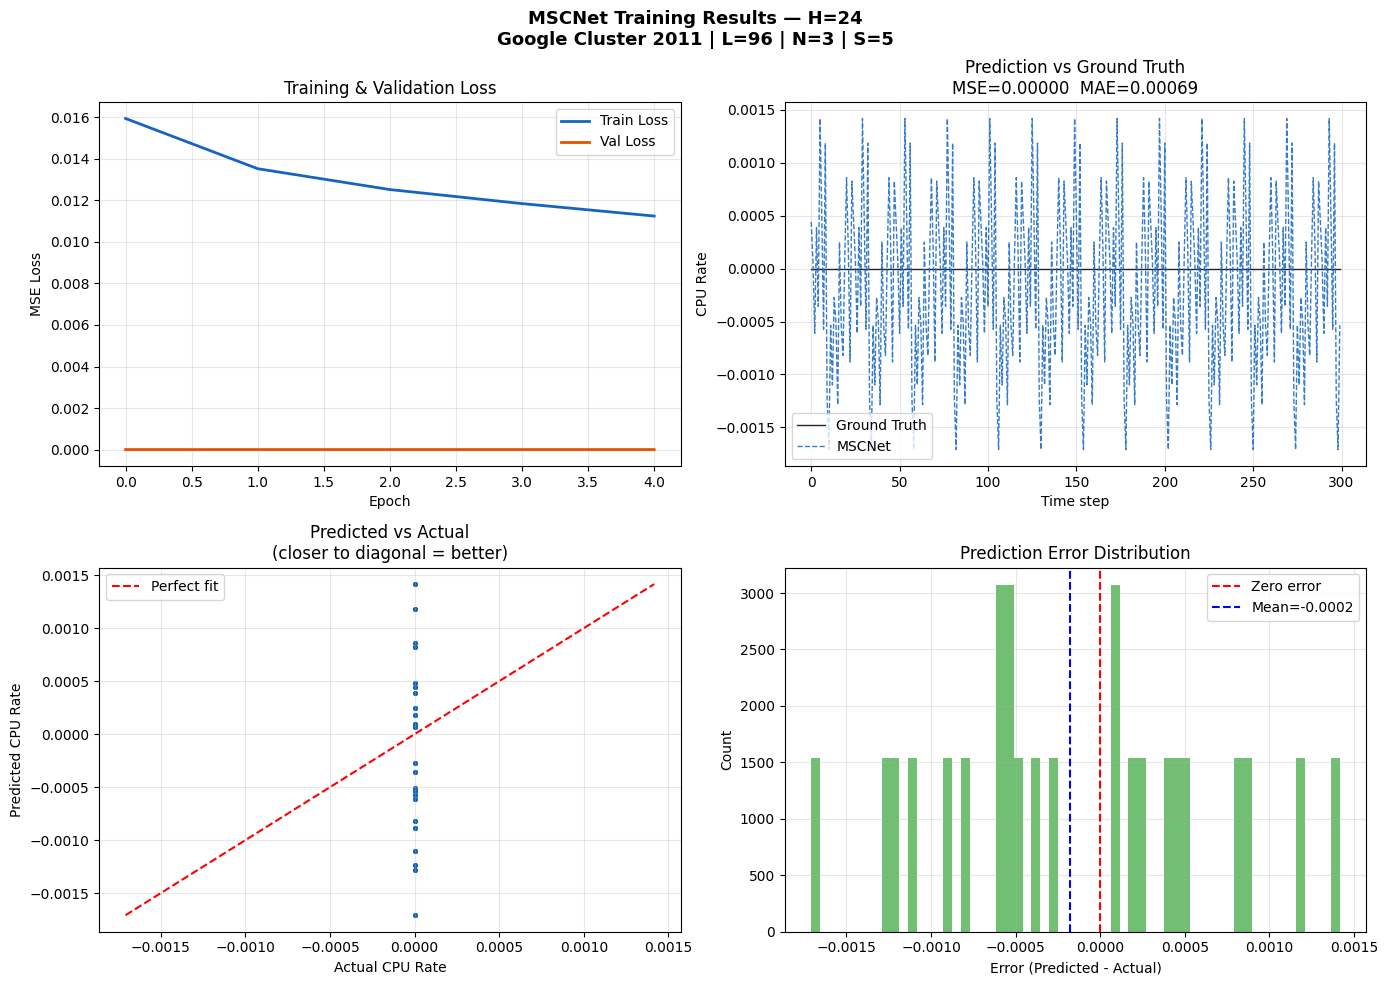

Saved: mscnet_review2_results.png


In [ ]:
# ============================================================
# CELL 18: Results Visualization (show in THIS review)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'MSCNet Training Results — H=24\n'
    'Google Cluster 2011 | L=96 | N=3 | S=5',
    fontsize=13, fontweight='bold'
)

# Plot 1: Training curves
ax = axes[0, 0]
ax.plot(tr_loss,  label='Train Loss',
        color='#1565C0', lw=2)
ax.plot(val_loss, label='Val Loss',
        color='#E65100', lw=2)
ax.set_title('Training & Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# Plot 2: Prediction vs Ground Truth (full)
ax = axes[0, 1]
n  = min(300, len(res_h24['yt']))
ax.plot(res_h24['yt'][:n],
        color='black',   lw=1.0,
        label='Ground Truth', alpha=0.85)
ax.plot(res_h24['yp'][:n],
        color='#1565C0', lw=1.0,
        label='MSCNet',  alpha=0.85,
        linestyle='--')
ax.set_title(
    f'Prediction vs Ground Truth\n'
    f'MSE={res_h24["MSE"]:.5f}  '
    f'MAE={res_h24["MAE"]:.5f}'
)
ax.set_xlabel('Time step')
ax.set_ylabel('CPU Rate')
ax.legend(); ax.grid(True, alpha=0.3)

# Plot 3: Scatter plot (pred vs true)
ax = axes[1, 0]
ax.scatter(
    res_h24['yt'][:500],
    res_h24['yp'][:500],
    alpha=0.4, s=5,
    color='#1565C0'
)
mn = min(res_h24['yt'].min(),
         res_h24['yp'].min())
mx = max(res_h24['yt'].max(),
         res_h24['yp'].max())
ax.plot([mn, mx], [mn, mx],
        'r--', lw=1.5, label='Perfect fit')
ax.set_title('Predicted vs Actual\n'
             '(closer to diagonal = better)')
ax.set_xlabel('Actual CPU Rate')
ax.set_ylabel('Predicted CPU Rate')
ax.legend(); ax.grid(True, alpha=0.3)

# Plot 4: Error distribution
ax = axes[1, 1]
errors = res_h24['yp'] - res_h24['yt']
ax.hist(errors, bins=60,
        color='#4CAF50', alpha=0.8,
        edgecolor='none')
ax.axvline(0,              color='red',
           linestyle='--', lw=1.5,
           label='Zero error')
ax.axvline(errors.mean(),  color='blue',
           linestyle='--', lw=1.5,
           label=f'Mean={errors.mean():.4f}')
ax.set_title('Prediction Error Distribution')
ax.set_xlabel('Error (Predicted - Actual)')
ax.set_ylabel('Count')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mscnet_review2_results.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mscnet_review2_results.png")

In [ ]:
# ============================================================
# CELL 19: Summary Table for THIS review
# ============================================================

print("""
╔══════════════════════════════════════════════════════╗
║          MSCNet — REVIEW 2 SUMMARY                  ║
╠══════════════════════════════════════════════════════╣
║  DATASET                                             ║
║  ─────────────────────────────────────────────────  ║
║  Source  : Google Cluster 2011                       ║
║  Machines: 100 selected                              ║
║  Duration: 29 days, 5-min intervals                  ║
║  Steps   : 8,352 time steps                          ║
║                                                      ║
║  PREPROCESSING                                       ║
║  ─────────────────────────────────────────────────  ║
║  Step 1: Load + fill missing values                  ║
║  Step 2: Bin into 5-min intervals                    ║
║  Step 3: Min-max scale per machine                   ║
║  RevIN  : Normalize per window inside model          ║
║                                                      ║
║  ARCHITECTURE (Table II — paper exact)               ║
║  ─────────────────────────────────────────────────  ║
║  L=96 | d=128 | N=3 | S=5 | dropout=0.2             ║
║  Adam | LR=1e-4 | decay=0.5 | patience=3             ║
║  Modules: RevIN + Trend + MSPB + TE + MSCB           ║
║                                                      ║
║  RESULTS (H=24)                                      ║
║  ─────────────────────────────────────────────────  ║""")

print(f"║  MSE  : {res_h24['MSE']:.6f}"
      f"                              ║")
print(f"║  MAE  : {res_h24['MAE']:.6f}"
      f"                              ║")
print(f"║  RMSE : {res_h24['RMSE']:.6f}"
      f"                              ║")

print("""║                                                      ║
║  PENDING (Final Review)                              ║
║  ─────────────────────────────────────────────────  ║
║  ⬜ H=48, 72, 96 results                             ║
║  ⬜ Baseline comparison (LSTM, Transformer)           ║
║  ⬜ Ablation study (remove each module)               ║
║  ⬜ Improvement % over baselines                      ║
╚══════════════════════════════════════════════════════╝""")


╔══════════════════════════════════════════════════════╗
║          MSCNet — REVIEW 2 SUMMARY                  ║
╠══════════════════════════════════════════════════════╣
║  DATASET                                             ║
║  ─────────────────────────────────────────────────  ║
║  Source  : Google Cluster 2011                       ║
║  Machines: 100 selected                              ║
║  Duration: 29 days, 5-min intervals                  ║
║  Steps   : 8,352 time steps                          ║
║                                                      ║
║  PREPROCESSING                                       ║
║  ─────────────────────────────────────────────────  ║
║  Step 1: Load + fill missing values                  ║
║  Step 2: Bin into 5-min intervals                    ║
║  Step 3: Min-max scale per machine                   ║
║  RevIN  : Normalize per window inside model          ║
║                                                      ║
║  ARCHITECTURE (Table II — paper